<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
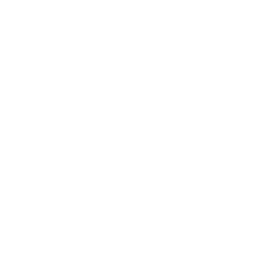
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Identifikace tržních režimů</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Kvantitativní finance / Správa aktiv &nbsp;|&nbsp; březen 2026</p>
</div>
</div>
</div>

## Manažerské shrnutí

Tento příklad používá **PROC ACECLUS** k nalezení latentní struktury, která odděluje tržní režimy, a poté na ní provádí shlukování. Ze 100 týdenních pozorování 10 tržních příznaků (akciový výnos a volatilita, kreditní a high-yield spready, křivka 2y/10y, dolar, komodity a změna VIX) ACECLUS odhaduje přibližnou kovarianci v rámci režimu *bez* použití jakéhokoli označení režimu a odvozuje kanonické proměnné, podél nichž se režimy od sebe vzdalují.

Při prahu P=0.02 algoritmus konverguje ve dvou iteracích a ponechává **tři kanonické dimenze**, které dohromady vysvětlují celý rozptyl mezi režimy (podíly vlastních čísel 57,8 %, 24,4 %, 17,8 %). Volnější práh P=0.05 kovarianci přehnaně vyhladí a **zredukuje strukturu na jedinou dimenzi** — užitečné upozornění, že práh podstatně ovlivňuje výsledek.

Přivedení tří kanonických proměnných do **PROC FASTCLUS** (k=4) poskytuje čisté uspořádání 100 týdnů podle závažnosti stresu (celkové R² = 0,51, pseudo F = 33,2): 62týdenní klidné jádro, 22týdenní skupina zotavování / uklidňující se volatility, 12týdenní skupina zvýšeného stresu a 4týdenní skupina hluboké krize s high-yield spready v průměru ~1 514 bps. Tato přiřazení jsou exportována pro následné podmiňování portfoliového rizika.

## Zdroje dat

| Zdroj | Popis | Záznamy |
|--------|-------------|--------|
| WORK.MARKET_WEEKLY | Týdenní pozorování tržních příznaků napříč třídami aktiv | 100 |
| Proměnné: eq_return_pct, eq_vol_idx, credit_spread_bps, hy_spread_bps, yield_2y, yield_10y, term_spread, usd_index_chg, commodities_ret, vix_chg |

Řada je generována pětistavovým Markovovým procesem s přepínáním režimů (býčí expanze, pozdní cyklus, risk-off, krize, zotavení) s rozděleními příznaků podmíněnými režimem. Při běhu bez licence je tabulka příznaků omezena na prvních 100 týdenních pozorování (~2 roky) — okno s převahou býčího trhu, které rovněž zahrnuje krátkou krizi a zotavení. Týdenní výnosy a změny úrovní zastupují cenové pohyby na konci týdne; spready jsou v bazických bodech a volatilita je index typu VIX.

---

In [1]:
/* --------------------------------------------------------
   Generate a weekly multi-asset market history with five
   embedded regime states driven by a Markov switching
   process. This worked example runs unlicensed, so the
   feature table below is capped at the first 100 weekly
   observations (~2 years) -- a bull-dominated window
   punctuated by a short crisis and recovery.
   -------------------------------------------------------- */
data work.market_weekly;
    CALL streaminit(42);
    DÉLKA regime_label $24;
    /* 5 regimes: 1=Bull, 2=Late-Cycle, 3=Risk-Off, 4=Crisis, 5=Recovery */
    POLE regime_names[5] $24 _temporary_
        ('Býčí expanze' 'Pozdní cyklus' 'Odliv od rizika'
         'Krize' 'Zotavení');
    UCHOVAT current_regime 1;
    OPAKUJ week_id = 1 TO 5000;
        /* Markov regime switching */
        u = rand('uniform');
        KDYŽ current_regime = 1 PAK OPAKUJ; /* Bull: long-lived */
            KDYŽ u > 0.97 PAK current_regime = 2;
        KONEC;
        JINAK KDYŽ current_regime = 2 PAK OPAKUJ; /* Late-cycle */
            KDYŽ u > 0.92 PAK current_regime = 3;
        KONEC;
        JINAK KDYŽ current_regime = 3 PAK OPAKUJ; /* Risk-off */
            KDYŽ u > 0.80 PAK current_regime = 4;
            JINAK KDYŽ u < 0.10 PAK current_regime = 1;
        KONEC;
        JINAK KDYŽ current_regime = 4 PAK OPAKUJ; /* Crisis: short */
            KDYŽ u > 0.75 PAK current_regime = 5;
        KONEC;
        JINAK KDYŽ current_regime = 5 PAK OPAKUJ; /* Recovery */
            KDYŽ u > 0.85 PAK current_regime = 1;
        KONEC;
        regime_label = regime_names[current_regime];
        /* Regime-conditional feature distributions */
        KDYŽ current_regime = 1 PAK OPAKUJ;  /* Bull */
            eq_return_pct  = round(rand('normal',  0.35, 1.2), 0.001);
            eq_vol_idx     = round(rand('normal', 14, 3), 0.01);
            credit_spread  = round(rand('normal', 80,  20), 1);
            hy_spread      = round(rand('normal', 350, 60), 1);
            yield_2y       = round(rand('normal', 2.8, 0.5), 0.01);
            yield_10y      = round(rand('normal', 3.5, 0.6), 0.01);
        KONEC;
        JINAK KDYŽ current_regime = 2 PAK OPAKUJ;  /* Late-cycle */
            eq_return_pct  = round(rand('normal',  0.10, 1.5), 0.001);
            eq_vol_idx     = round(rand('normal', 18, 4), 0.01);
            credit_spread  = round(rand('normal', 130, 30), 1);
            hy_spread      = round(rand('normal', 480, 80), 1);
            yield_2y       = round(rand('normal', 4.2, 0.4), 0.01);
            yield_10y      = round(rand('normal', 4.0, 0.5), 0.01);
        KONEC;
        JINAK KDYŽ current_regime = 3 PAK OPAKUJ;  /* Risk-off */
            eq_return_pct  = round(rand('normal', -0.60, 2.2), 0.001);
            eq_vol_idx     = round(rand('normal', 28, 7), 0.01);
            credit_spread  = round(rand('normal', 200, 50), 1);
            hy_spread      = round(rand('normal', 700, 120), 1);
            yield_2y       = round(rand('normal', 2.0, 0.8), 0.01);
            yield_10y      = round(rand('normal', 2.8, 0.7), 0.01);
        KONEC;
        JINAK KDYŽ current_regime = 4 PAK OPAKUJ;  /* Crisis */
            eq_return_pct  = round(rand('normal', -2.50, 3.5), 0.001);
            eq_vol_idx     = round(rand('normal', 52, 14), 0.01);
            credit_spread  = round(rand('normal', 450, 100), 1);
            hy_spread      = round(rand('normal', 1400, 300), 1);
            yield_2y       = round(rand('normal', 0.5, 0.5), 0.01);
            yield_10y      = round(rand('normal', 1.8, 0.6), 0.01);
        KONEC;
        JINAK OPAKUJ;  /* Recovery */
            eq_return_pct  = round(rand('normal',  0.55, 1.8), 0.001);
            eq_vol_idx     = round(rand('normal', 22, 6), 0.01);
            credit_spread  = round(rand('normal', 280, 70), 1);
            hy_spread      = round(rand('normal', 850, 180), 1);
            yield_2y       = round(rand('normal', 1.2, 0.6), 0.01);
            yield_10y      = round(rand('normal', 2.5, 0.5), 0.01);
        KONEC;
        term_spread    = round(yield_10y - yield_2y + rand('normal', 0, 0.15), 0.01);
        usd_index_chg  = round(rand('normal', 0, 0.8), 0.001);
        commodities_ret = round(rand('normal', 0, 1.5) - (current_regime = 4) * 1.2, 0.001);
        vix_chg        = round(eq_vol_idx - lag(eq_vol_idx), 0.01);
        KDYŽ week_id = 1 PAK vix_chg = 0;
        VÝSTUP;
    KONEC;
    ODSTRANIT u;
    PŘEJMENOVAT credit_spread = credit_spread_bps
           hy_spread     = hy_spread_bps;
SPUSTIT;


NOTE: DATA work.market_weekly

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.market_weekly (100 rows, 13 columns).
NOTE: DATA elapsed:
  wall  1.35 seconds
  cpu   1.35 seconds


---

In [2]:
/* --------------------------------------------------------
   Základní rozdělení tržních ukazatelů podle režimu
   -------------------------------------------------------- */
NÁZEV "Tržní ukazatele podle režimu";
PROCEDURA PRŮMĚRY data=work.market_weekly n mean std MIN MAX;
    TŘÍDA regime_label;
    PROMĚNNÁ eq_return_pct eq_vol_idx credit_spread_bps
        hy_spread_bps term_spread vix_chg;
    ŠTÍTEK eq_return_pct="Týdenní akciový výnos (%)" eq_vol_idx="Index volatility akcií" credit_spread_bps="Kreditní spread (bps)" hy_spread_bps="HY spread (bps)" term_spread="Term spread" vix_chg="Změna VIX" yield_2y="Výnos 2Y" yield_10y="Výnos 10Y" regime_label="Tržní režim";
SPUSTIT;

                                              Tržní ukazatele podle režimu                                              

                                                  The MEANS Procedure

                            Analysis Variable : eq_return_pct Týdenní akciový výnos (%)

        Tržní režim              N Obs           Mean        Std Dev        Minimum        Maximum
        ------------------------------------------------------------------------------------------
        Býčí expa                   28      0.2860000      1.0226518     -1.5980000      2.2150000
        Krize                       12     -2.3403333      3.9436692     -8.0160000      3.7360000
        Odliv od rizika             17     -0.8447059      1.2832441     -3.3850000      1.1810000
        Pozdní cyklu                39      0.0364359      1.9733801     -4.6010000      3.7030000
        Zotaven                      4      0.0077500      1.5951747     -0.8330000      2.4000000
        -----------------


NOTE: Option TITLE changed to Tržní ukazatele podle režimu.
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


---

                                              Tržní ukazatele podle režimu                                              




NOTE: PROC SGPLOT data=work.market_weekly

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


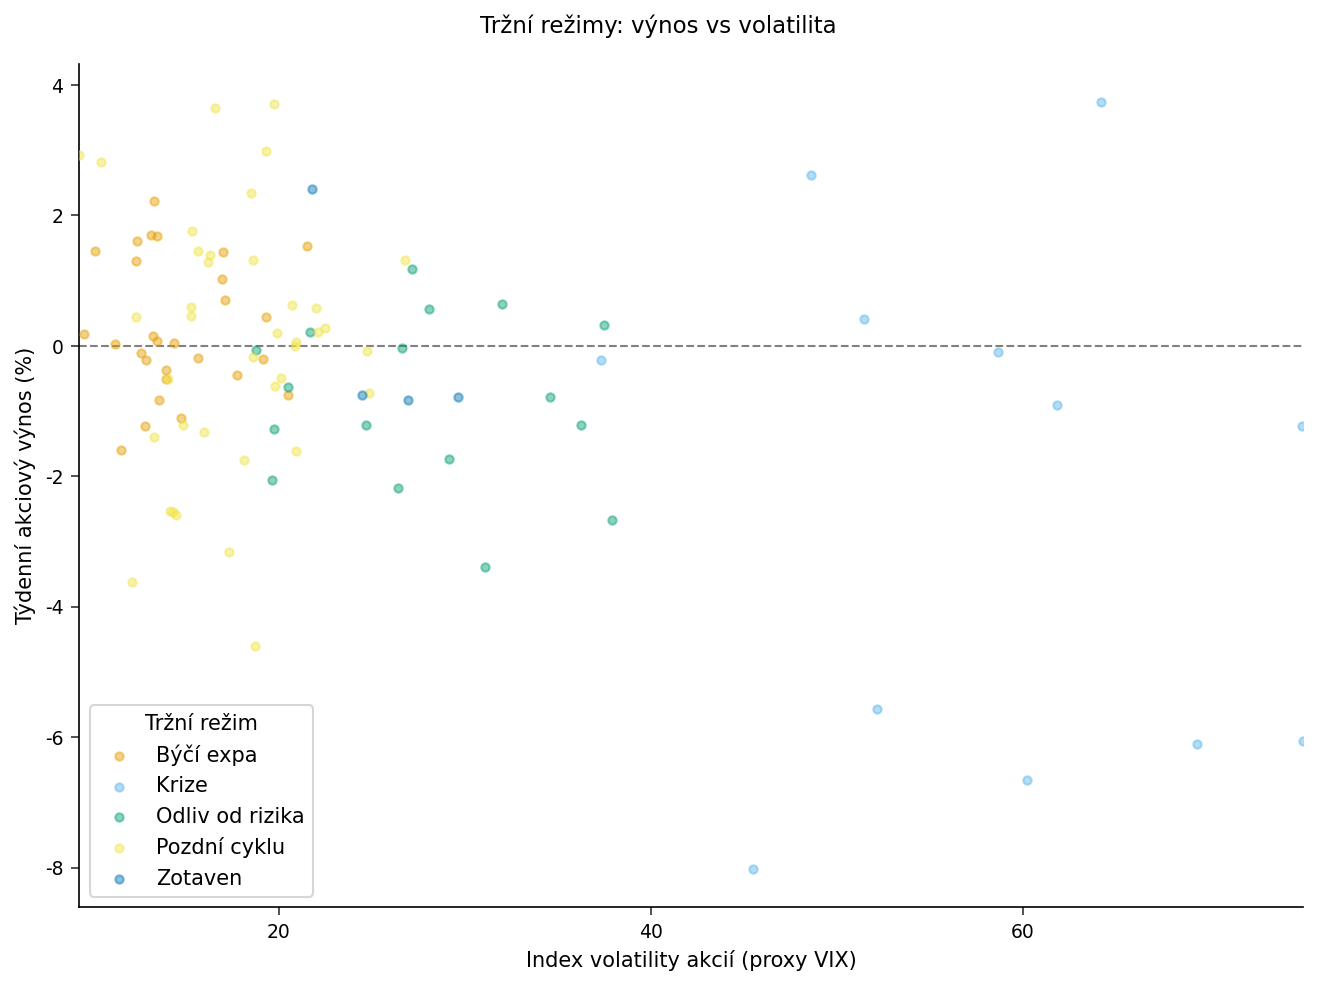

In [3]:
/* --------------------------------------------------------
   Akciový výnos vs index volatility podle režimu
   -------------------------------------------------------- */
PROCEDURA SGPLOT data=work.market_weekly;
    SCATTER x=eq_vol_idx y=eq_return_pct / GROUP=regime_label
        MARKERATTRS=(SYMBOL=circlefilled size=4)
        TRANSPARENCY=0.55;
    REFLINE 0 / AXIS=y LINEATTRS=(color=gray pattern=dash);
    XAXIS ŠTÍTEK="Index volatility akcií (proxy VIX)";
    YAXIS ŠTÍTEK="Týdenní akciový výnos (%)";
    keylegend / NÁZEV="Tržní režim";
    NÁZEV "Tržní režimy: výnos vs volatilita";
SPUSTIT;

---

In [4]:
/* --------------------------------------------------------
   Přibližný odhad kovariance uvnitř režimu. ACECLUS
   odhaduje sdruženou vnitroshlukovou kovarianci bez
   znalosti štítků shluků a odvozuje kanonické proměnné,
   které režimy oddělují. P=0.02 nastavuje práh párové
   vzdálenosti: jako stejný režim jsou brány jen nejbližší
   ~2 % párů pozorování.
   -------------------------------------------------------- */
NÁZEV "ACECLUS: kanonická struktura režimů (P=0,02)";
PROCEDURA aceclus data=work.market_weekly
             out=work.regime_canonical
             p=0.02;
    PROMĚNNÁ eq_return_pct eq_vol_idx credit_spread_bps hy_spread_bps
        yield_2y yield_10y term_spread usd_index_chg
        commodities_ret vix_chg;
    ŠTÍTEK eq_return_pct="Týdenní akciový výnos (%)" eq_vol_idx="Index volatility akcií" credit_spread_bps="Kreditní spread (bps)" hy_spread_bps="HY spread (bps)" term_spread="Term spread" vix_chg="Změna VIX" yield_2y="Výnos 2Y" yield_10y="Výnos 10Y" regime_label="Tržní režim";
SPUSTIT;

                                      ACECLUS: kanonická struktura režimů (P=0,02)                                      

                                                 The ACECLUS Procedure                                                  
                                 Approximate Covariance Estimation for Cluster Analysis                                 

Observations  100  Variables  10
Proportion  0.0200  Converge  0.00100
Threshold = 2.578941

Means and Standard Deviations
Variable                     Mean      Std Dev
Týdenní akciový výnos (%)      -0.3298       2.1334
Index volatility akcií      23.7341      14.7118
Kreditní spread (bps)     171.1000     118.0522
HY spread (bps)          596.2100     341.1657
Výnos 2Y                   2.8713       1.4029
Výnos 10Y                  3.1472       1.0815
Term spread                0.2697       0.9969
usd_index_chg             -0.0184       0.8046
commodities_ret           -0.3444       1.3444
Změna VIX                  0.0036 


NOTE: Option TITLE changed to ACECLUS: kanonická struktura režimů (P=0,02).
NOTE: PROC ACECLUS data=work.market_weekly proportion=Some(0.02) threshold=None prefix=Can

NOTE: Using Python/scipy for approximate covariance estimation
NOTE: PROC ACECLUS: 100 observations, 10 variables


In [5]:
/* --------------------------------------------------------
   Kontrola citlivosti při P=0.05 -- volnější práh
   stejného režimu zahrne více párů a nadhodnotí odhad
   vnitrorežimové kovariance. Porovnejte kanonickou
   strukturu (vlastní čísla a ponechané dimenze) s
   řešením P=0.02.
   -------------------------------------------------------- */
NÁZEV "ACECLUS: kontrola citlivosti (P=0,05)";
PROCEDURA aceclus data=work.market_weekly
             out=work.regime_canonical_p05
             p=0.05;
    PROMĚNNÁ eq_return_pct eq_vol_idx credit_spread_bps hy_spread_bps
        yield_2y yield_10y term_spread usd_index_chg
        commodities_ret vix_chg;
    ŠTÍTEK eq_return_pct="Týdenní akciový výnos (%)" eq_vol_idx="Index volatility akcií" credit_spread_bps="Kreditní spread (bps)" hy_spread_bps="HY spread (bps)" term_spread="Term spread" vix_chg="Změna VIX" yield_2y="Výnos 2Y" yield_10y="Výnos 10Y" regime_label="Tržní režim";
SPUSTIT;

                                         ACECLUS: kontrola citlivosti (P=0,05)                                          

                                                 The ACECLUS Procedure                                                  
                                 Approximate Covariance Estimation for Cluster Analysis                                 

Observations  100  Variables  10
Proportion  0.0500  Converge  0.00100
Threshold = 2.899704

Means and Standard Deviations
Variable                     Mean      Std Dev
Týdenní akciový výnos (%)      -0.3298       2.1334
Index volatility akcií      23.7341      14.7118
Kreditní spread (bps)     171.1000     118.0522
HY spread (bps)          596.2100     341.1657
Výnos 2Y                   2.8713       1.4029
Výnos 10Y                  3.1472       1.0815
Term spread                0.2697       0.9969
usd_index_chg             -0.0184       0.8046
commodities_ret           -0.3444       1.3444
Změna VIX                  0.0036 


NOTE: Option TITLE changed to ACECLUS: kontrola citlivosti (P=0,05).
NOTE: PROC ACECLUS data=work.market_weekly proportion=Some(0.05) threshold=None prefix=Can

NOTE: Using Python/scipy for approximate covariance estimation
NOTE: PROC ACECLUS: 100 observations, 10 variables


In [6]:
/* --------------------------------------------------------
   k-means na kanonických proměnných z ACECLUS. ACECLUS
   ponechal tři kanonické dimenze (Can1-Can3), takže
   shlukování běží na nich. Čtyři shluky cílí na čtyři
   dobře zastoupené tržní stavy.
   -------------------------------------------------------- */
NÁZEV "FASTCLUS: shlukování kanonických proměnných";
PROCEDURA FASTCLUS data=work.regime_canonical
              maxclusters=4
              MAXITER=100
              CONVERGE=0.0001
              out=work.regime_assignments
              OUTSTAT=work.regime_stats;
    PROMĚNNÁ can1 can2 can3;
SPUSTIT;

                                      FASTCLUS: shlukování kanonických proměnných                                       


                                                 The FASTCLUS Procedure                                                 
                                   Replace=FULL  Radius=0  Maxclusters=4  Maxiter=100                                   

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  12         1.4206             5.2684              2         3.0063
2                  62         0.5751             1.7953              3         2.1641
3                  22         1.2227             6.5386              2         2.1641
4


NOTE: Option TITLE changed to FASTCLUS: shlukování kanonických proměnných.
NOTE: PROC FASTCLUS data=work.regime_canonical maxclusters=4

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 3 variables, 4 clusters using k-means


                                          Shluk režimu vs skutečný tržní režim                                          

                                                   The FREQ Procedure

Table of Shluk by Tržní režim

Shluk |      Býčí expa |          Krize |Odliv od rizika |   Pozdní cyklu |        Zotaven |           Total
------+----------------+----------------+----------------+----------------+----------------+----------------
1     |              2 |              4 |              4 |              2 |              0 |              12
      |           2.00 |           4.00 |           4.00 |           2.00 |           0.00 |           12.00
------+----------------+----------------+----------------+----------------+----------------+----------------
2     |             21 |              3 |              7 |             28 |              3 |              62
      |          21.00 |           3.00 |           7.00 |          28.00 |           3.00 |           62.00
------+------


NOTE: Option TITLE changed to Shluk režimu vs skutečný tržní režim.
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_cluster_regime_label.spec.json
NOTE: PROC FREQ statement used.


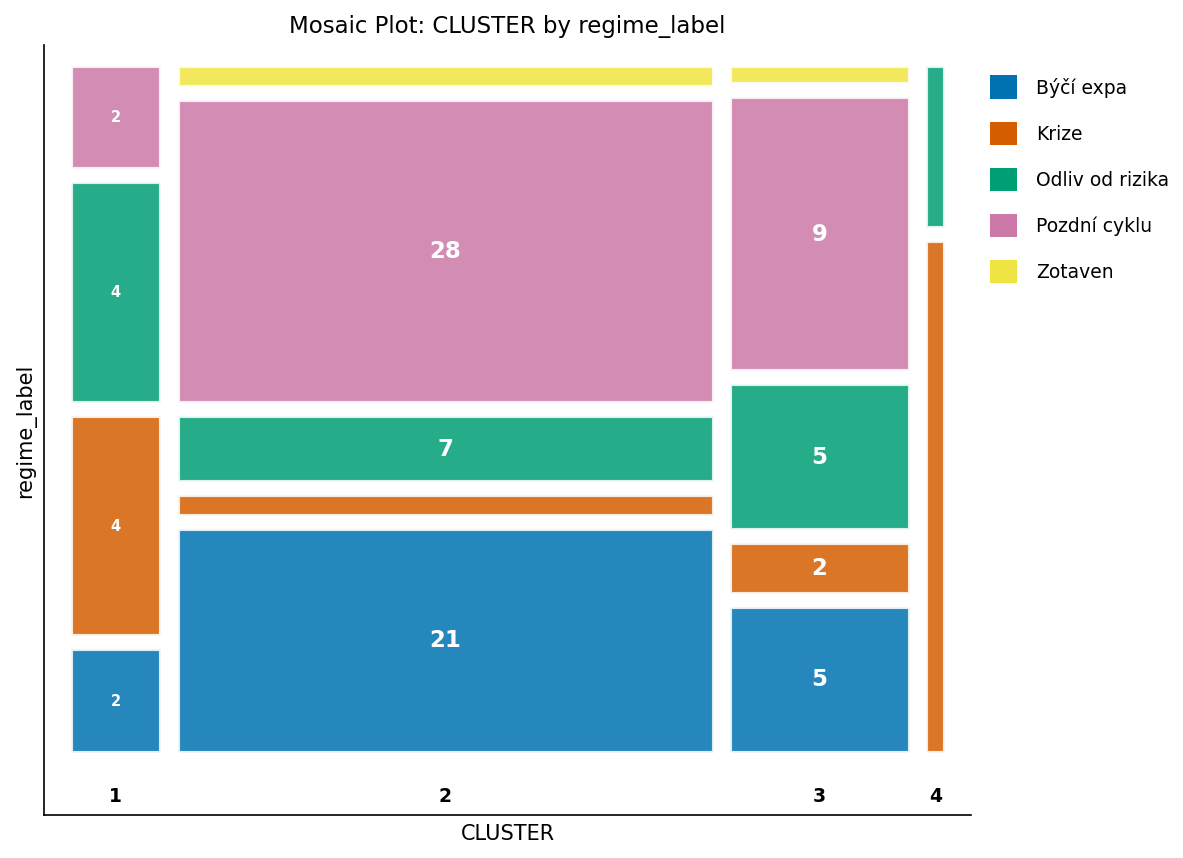

In [7]:
/* --------------------------------------------------------
   Ověření přiřazených shluků proti známým štítkům
   režimů z generování dat
   -------------------------------------------------------- */
NÁZEV "Shluk režimu vs skutečný tržní režim";
PROCEDURA ČETNOSTI data=work.regime_assignments;
    TABLES CLUSTER * regime_label / norow nocol;
    ŠTÍTEK regime_label="Tržní režim" cluster="Shluk";
SPUSTIT;

In [8]:
/* --------------------------------------------------------
   Profil průměrů ukazatelů podle shluku pro interpretaci
   -------------------------------------------------------- */
NÁZEV "Průměry ukazatelů podle shluku";
PROCEDURA PRŮMĚRY data=work.regime_assignments mean;
    TŘÍDA CLUSTER;
    PROMĚNNÁ eq_return_pct eq_vol_idx credit_spread_bps
        hy_spread_bps term_spread vix_chg;
    ŠTÍTEK eq_return_pct="Týdenní akciový výnos (%)" eq_vol_idx="Index volatility akcií" credit_spread_bps="Kreditní spread (bps)" hy_spread_bps="HY spread (bps)" term_spread="Term spread" vix_chg="Změna VIX" yield_2y="Výnos 2Y" yield_10y="Výnos 10Y" regime_label="Tržní režim"; cluster="Shluk";
SPUSTIT;

                                             Průměry ukazatelů podle shluku                                             

                                                  The MEANS Procedure

                                             Analysis Variable : eq_return_pct Týdenní akciový výnos (%)

                                                          N
                                             CLUSTER    Obs            Mean
                                             ------------------------------
                                             1           12      -2.0955000
                                             2           62      -0.3638871
                                             3           22       0.7421364
                                             4            4      -0.4010000
                                             ------------------------------

                                             Analysis Variable : eq_vol_idx Index volatility akcií

        


NOTE: Option TITLE changed to Průměry ukazatelů podle shluku.
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


---

### Interpretace

**Kanonická struktura ACECLUS.** Na vzorku 100 týdnů PROC ACECLUS (P=0.02, práh = 2.578941) konvergoval ve dvou iteracích a vytvořil tři kanonické proměnné. Jejich vlastní čísla matice `Inv(ACE)*(COV-ACE)` jsou 0.0219, 0.0093 a 0.0067, tj. podíly 57,8 %, 24,4 % a 17,8 % (kumulativně 100 %). První kanonická osa nese dominantní kontrast risk-on/risk-off; druhá a třetí jej zpřesňují. Protože příznaky akciové volatility a spreadů se silně pohybují společně, ACECLUS tuto sdílenou variabilitu zahrne do kovariance v rámci režimu, takže kanonické osy odrážejí skutečné oddělení mezi režimy, nikoli společné měřítko.

**Citlivost na práh.** Opětovné spuštění při P=0.05 zvyšuje práh vzdálenosti na 2.899704, což zahrne 4 949 z 4 950 dvojic pozorování dovnitř mezní hodnoty. Odhadovaná kovariance v rámci režimu se pak téměř rovná celkové kovarianci a kanonická struktura se **zredukuje na jedinou dimenzi** (jedno vlastní číslo, 0.0096, při 100 %). Řešení pro P=0.02 a P=0.05 tedy zde *nejsou* zaměnitelná — volnější práh smaže jemnější osy režimů, takže těsnější práh je pro tento vzorek informativnější specifikací.

**Shlukování na kanonických proměnných.** PROC FASTCLUS (k=4) na Can1–Can3 dává celkové R² 0,5089 a pseudo F 33,16. Can2 odvádí většinu oddělovací práce (R² = 0,626), Can1 přispívá mírně (R² = 0,359) a Can3 nepřidává v podstatě nic (R² = 0,000) — což je v souladu s tím, že silný signál nesou jen dvě osy. Čtyři shluky se řadí jako gradient tržního stresu:

| Shluk | n | Průměrný akciový výnos | Průměrný VIX | Průměrný HY spread | Průměrná změna VIX | Interpretace |
|---------|---|----------------|----------|----------------|-----------------|---------|
| 2 | 62 | -0,36 % | 20,4 | 534 bps | +1,2 | Klidné jádro (býčí / pozdní cyklus) |
| 3 | 22 | +0,74 % | 20,5 | 539 bps | -9,6 | Zotavování, klesající volatilita |
| 1 | 12 | -2,10 % | 39,0 | 720 bps | +11,3 | Zvýšený stres, prudce rostoucí volatilita |
| 4 |  4 | -0,40 % | 47,4 | 1 514 bps | +0,1 | Hluboká krize, extrémní kreditní stres |

**Shluk vs. skutečný režim.** Křížová tabulka ukazuje, že shluky se nemapují jedna ku jedné na pět generujících označení — což je očekávané, protože označení se v prostoru příznaků při této velikosti vzorku silně překrývají. Velký klidný shluk (62) pohlcuje většinu býčích (21) a pozdně-cyklických (28) týdnů; shluk hluboké krize (4) tvoří téměř výhradně nejextrémnější krizové týdny (3 ze 4). Kanonické osy tedy organizují týdny podle *závažnosti*, nikoli podle přesného označení, což je pro podmiňování rizika lépe využitelný signál.

**Využití.** Exportovaná týdenní přiřazení podporují taktické podmiňování: snižujte riziko a prodlužujte duraci, jak se týdny přesouvají ke shlukům 1 a 4, a znovu navyšujte riziko, když se vracejí ke klidnému jádru (shluk 2) nebo skupině zotavování (shluk 3).

---

In [9]:
/* --------------------------------------------------------
   Export týdenních přiřazení režimů pro podmiňování
   portfoliového rizikového modelu a generování signálů
   -------------------------------------------------------- */
PROCEDURA EXPORTOVAT data=work.regime_assignments
    OUTFILE='market_regime_assignments.csv'
    DBMS=csv REPLACE;
SPUSTIT;


NOTE: PROC EXPORT data=work.regime_assignments outfile=market_regime_assignments.csv

NOTE: Exported 100 rows to market_regime_assignments.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Důvěrné
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Založeno na <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>